# Project 1 - AirBNB Price Prediction
**Group 11**

Justin Kung jkungcc@ubc.ca 28477289 <br>
Samantha Chen samjnc@student.ubc.ca 93314763 <br>
Omar Elnashar omareln@student.ubc.ca 66602582

# Introduction
Airbnb is an online marketplace for temporary housing and lodging services. Sellers can offer their properties for rent at different rates depending on multiple factors. Similar to any other service or product, the pricing of an Airbnb by the seller is crucial to maintaining high rental rates. If the price is too high, customers will be deterred from purchasing. If the price is too low, customers will question the quality of the Airbnb provided. 

In order to establish an equilibrium price for Airbnbs, a price estimator is needed to be built based on the multiple factors of differentiation of an Airbnb. These factors include: accommodation capacity, bathrooms, neighbourhood, price, and unit type. A linear regression plot will be used to find the coefficient of determination between price (y) and num_beds (x). We hypothesize that there is a positive correlation between price and the number of beds within an Airbnb unit. As per the project description, we will be sticking to one predictor variable (num_beds) so that the result is a Linear Regression.

In [1]:
#import necessary libraries pandas, numpy, and matplotlib.pyplot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  

# Data Preparation
We first read in the data file, after which we exclude the indexes of each data set from our data to decrease redundancy. After previewing the data set to check if the data has been imported correctly, we remove duplicate records. The purpose of this step is to ensure no repetition within our sample set, which would skew the regression in favor of most common housing types. Finally, any records containing an NA value within its data are removed for optimum results.

In [2]:
# Read in the airbnb data file using pandas read_csv method
airbnb = pd.read_csv("airbnb data.csv")

# Drop the numbered index column to decrease redundancy
airbnb = airbnb.drop("Unnamed: 0", 1)

# Preview the start/format of the data to make sure it's imported correctly
airbnb.head()

,accommodates,bathrooms,neighbourhood,num_beds,price,property_type
0,1.0,1.0,Kitsilano,1,39,Apartment
1,1.0,1.0,Kensington-Cedar Cottage,1,43,Townhouse
2,2.0,1.0,Dunbar-Southlands,1,20,Apartment
3,3.0,1.0,Fraserview,1,49,Bed and breakfast
4,2.0,1.0,Oakridge,1,49,Villa


In [3]:
# Remove duplicate records
airbnb.drop_duplicates()

,accommodates,bathrooms,neighbourhood,num_beds,price,property_type
0,1.0,1.0,Kitsilano,1,39,Apartment
1,1.0,1.0,Kensington-Cedar Cottage,1,43,Townhouse
2,2.0,1.0,Dunbar-Southlands,1,20,Apartment
3,3.0,1.0,Fraserview,1,49,Bed and breakfast
4,2.0,1.0,Oakridge,1,49,Villa
...,...,...,...,...,...,...
404,7.0,3.0,Grandview-Woodland,5,234,House
405,5.0,2.5,Kitsilano,5,249,House
406,4.0,1.0,Mount Pleasant,5,224,House
407,6.0,1.5,Riley Park,5,220,House


In [4]:
# Remove any records with NA values
airbnb.dropna()

,accommodates,bathrooms,neighbourhood,num_beds,price,property_type
0,1.0,1.0,Kitsilano,1,39,Apartment
1,1.0,1.0,Kensington-Cedar Cottage,1,43,Townhouse
2,2.0,1.0,Dunbar-Southlands,1,20,Apartment
3,3.0,1.0,Fraserview,1,49,Bed and breakfast
4,2.0,1.0,Oakridge,1,49,Villa
...,...,...,...,...,...,...
404,7.0,3.0,Grandview-Woodland,5,234,House
405,5.0,2.5,Kitsilano,5,249,House
406,4.0,1.0,Mount Pleasant,5,224,House
407,6.0,1.5,Riley Park,5,220,House


# Variables to consider
We want to predict the Y variable using our X variable: <br>
<br>
**quantitative** = num_beds, bathrooms, accommodates <Br>
**qualitative** = neighbourhood, property_type
<br>
<br>
For the purposes of this initial regression:
<br>
<br>
**y** = price <br>
**x** = num_beds <br>

# Numerical Summary of Data

In [5]:
# GIves a brief summary of the dataset
airbnb.describe()

,accommodates,bathrooms,num_beds,price
count,409.000000,410.000000,410.000000,410.000000
mean,3.234719,1.256098,2.736585,119.036585
std,1.854689,0.543037,1.188321,56.056042
min,1.000000,1.000000,1.000000,13.000000
25%,2.000000,1.000000,2.000000,83.000000
50%,2.000000,1.000000,3.000000,112.000000
75%,4.000000,1.000000,4.000000,155.000000
max,13.000000,4.000000,5.000000,249.000000


# Methodology 
The aim of our investigation is to identify the price (y), depending on variables (x). In this scenario, we will be focusing on the quantitative variables that constitute an Aribnb’s value. The (x) variable is the number of beds available. Once again, the (y) variable is price. 

In [6]:
# Create separate variables for x and y
X = airbnb["num_beds"]
y = airbnb["price"]

# Preview X
X = X[~np.isnan(X)] # Removes NaN values
X.view()

0      4.940656e-324
1      4.940656e-324
2      4.940656e-324
3      4.940656e-324
4      4.940656e-324
           ...      
405    2.470328e-323
406    2.470328e-323
407    2.470328e-323
408    4.940656e-324
409    4.940656e-324
Name: num_beds, Length: 410, dtype: float64

In [7]:
# Preview Y
y.view()

0      1.926856e-322
1      2.124482e-322
2      9.881313e-323
3      2.420922e-322
4      2.420922e-322
           ...      
405    1.230223e-321
406    1.106707e-321
407    1.086944e-321
408    6.422853e-323
409    1.926856e-322
Name: price, Length: 410, dtype: float64

In order to establish the most accurate results, we will split our data set into training and testing sets. The training set constitutes 80% of the data, and will be used by the machine to understand the regression and establish a relationship between the (y) and (x) variables. While the remaining 20% will be used to test and apply the regression established to data that has not been seen by the machine yet. 

In [8]:
# Import train_test_split from Sklearn package
from sklearn.model_selection import train_test_split

In [9]:
# Create the split, test data size will be 20% of the total dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [10]:
# .predict and .score functions only take 2D arrays for X, therefore we must reshape our numpy arrays using .values.reshape(-1, 1)

X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

In [11]:
# Training dataset is 80% of the records in the airbnb dataframe
len(X_train)

328

In [12]:
# Testing dataset is 20% of the records in the airbnb dataframe
len(X_test)

82

Following splitting the data set, a linear regression model is needed to establish a relationship between (x) and (y). Thus, we imported the LinearRegression function from sklearn.linear_model. Next, the training data set was fitted to the linear regression model using the fit function. After the model has been established, it is now used to predict the values of the testing set. 

In [13]:
# Import LinearRegression function from sklearn.linear_model
from sklearn.linear_model import LinearRegression

clf = LinearRegression()

In [14]:
# Fits the training sets to the linear regression model we just initialized

clf.fit(X_train, y_train)

LinearRegression()

In [15]:
# Use the model to predict scores based on x_test

y_pred = clf.predict(X_test)

In [16]:
# Actual values of y_test
compare_y = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
compare_y

,Actual,Predicted
155,89,85.164823
32,30,39.288536
342,160,176.917399
332,169,176.917399
45,49,39.288536
...,...,...
126,100,85.164823
333,178,176.917399
246,148,131.041111
226,112,131.041111


In [17]:
# Return the intercept value of our linear regression

print(clf.intercept_)

-6.587752336541712


In [18]:
# Return the coefficients of each x variable (their relative values to each increase in num_beds and bathrooms)

print(clf.coef_)

[45.87628784]


Now that we have performed our Linear Regression, we use the .intercept_ and .coef_ functions to print our Linear Regression Equation:
<br>
<br>

<div align="center">
    $ y = mx + b $ <br>
    $ y = 45.88x - 6.59 $ <br>
<br>
    
<div align="left">
In plain english,  our equation states that for every additional bedroom, we can expect the price to rise by $45.90.


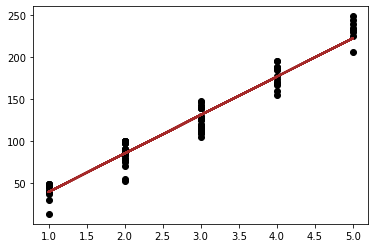

In [19]:
# Plot the price vs. num_beds relationship

plt.scatter(X_test, y_test,  color='black')
plt.plot(X_test, y_pred, color='brown', linewidth=2)
plt.show()

The final step in our methodology is to discover the accuracy of the findings. To do this, we compared the actual values of our testing data set (clf.predict(x_test)) to the actual y-test values. Using the .score() function, we calculated the accuracy score of our linear regression model which amounted to 0.945, or 95%.

In [20]:
# Tells us the "accuracy score" of our linear regression model, compares the values of clf.predict(x_test) and the actual y_test values

clf.score(X_test, y_test)

0.9451638260020575

This tells us the coefficient of determination (R^2) of our linear regression model is 95.2%, which means that 95.2% of the variation in price can be accounted for by a change in the num_beds variable.

# Further Investigation using "bathrooms" variable

Using the same algorithm that we utilized for num_beds, it is beneficial for us to attempt the same test using a different quantitiative variable such as "# of bathrooms" to see if we can produce a more accurate (higher R^2 value) model than that of our num_beds model.

In [21]:
# Create separate variables for x and y
X2 = airbnb["bathrooms"]
y2 = airbnb["price"]

# Split the dataset into training and testing sets (80/20 split)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2)

# Reshape the numpy arrays
X_train2 = X_train2.values.reshape(-1, 1)
X_test2 = X_test2.values.reshape(-1, 1)

# Create a variable to hold the linear regression
clf2 = LinearRegression()

# Fit the training sets to the regression model
clf2.fit(X_train2, y_train2)

# Predict y using x_test
y_pred2 = clf2.predict(X_test2)

In [22]:
#View a comparison of actual price versus our predictions from our regression model.

compare_y2 = pd.DataFrame({'Actual': y_test2, 'Predicted': y_pred2})
compare_y2

,Actual,Predicted
300,115,113.396767
38,39,113.396767
224,148,113.396767
227,119,113.396767
407,220,124.198375
...,...,...
337,188,113.396767
221,139,113.396767
306,174,124.198375
364,190,124.198375


In [23]:
# Return the intercept value of our linear regression

print(clf2.intercept_)

# Return the coefficients of each x variable (their relative values to each increase in num_beds and bathrooms)

print(clf2.coef_)

91.79354955667623
[21.60321698]


For our Linear Regression using bathroom, we again use the .intercept_ and .coef_ functions to print our equation:
<br>
<br>

<div align="center">
    $ y = mx1 + mx2 + b $ <br>
    $ y = 21.60x + 91.79 $ <br>
<br>
    
<div align="left">
Our equation states that for every additional bathroom, we can expect the price to rise by 21.60 dollars.

In [24]:
# Tells us the "accuracy score" of our linear regression model, compares the values of clf.predict(x_test) and the actual y_test values

clf.score(X_test2, y_test2)

-1.8150218816895571

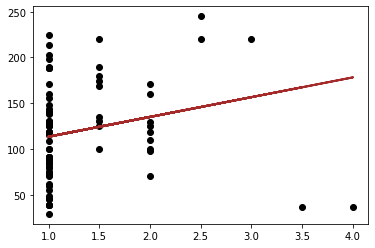

In [25]:
# Plot the regression model

plt.scatter(X_test2, y_test2,  color='black')
plt.plot(X_test2, y_pred2, color='brown', linewidth=2)
plt.show()

From using bathroom as the independent x variable, there are a lot of bad signs. Firstly, bathrooms produced a nonsensical coefficient of determination when using the .score() function. The coefficient of determination can only be $ -1 < x < 1 $, therefore this does not provide any information on how accurate our algorithm performed. Secondly, the line of best fit **does not** account for most of our data points. These points suggest that bathrooms is **not** a reliable predictor variable for this type of model.

# Conclusion
Following the setting up, training, and testing of our data set using a regression model, we conclude that there is a positive and accurate correlation between the price of an Airbnb and the number of beds it contains. The R^2 value of our model is 95%, which falls in line with our initial hypothesis. Lastly, from further tests such as number of bathrooms, we were not able to find a more accurate model than num_beds.
<br> 
<br>
Although qualitative factors such as neighborhood and building type were not used for the analysis, it is estimated that their effect on the price would not be as impactful as the two variables used.